## Objective
Perform EDA on the Agriculture Crop Yield dataset to understand the data structure,
identify issues, analyze feature relationships, and prepare observations for the preprocessing phase.

## Dataset
- Source: Kaggle — Agriculture Crop Yield Dataset
- Target Variable: Yield_tons_per_hectare
- Total Features: 10 columns

## Step 1 — Import Libraries

Importing all required libraries for data analysis and visualization.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully
Pandas version: 3.0.1
NumPy version: 2.4.3


## Step 2 — Load Dataset

Loading the raw CSV file and confirming it loaded correctly by checking shape and first few rows.

In [24]:
df = pd.read_csv('../Data/Agriculture_Crop_Yield/crop_yield.csv')

print("Dataset loaded successfully")
print(f"Shape: {df.shape}")

Dataset loaded successfully
Shape: (1000000, 10)


## Step 3 — Dataset Structure (df.info)

Checking column names, data types, and non-null counts.
This tells us if any columns have wrong data types or missing values.

In [25]:
print("DATASET INFO")
print("="*50)
df.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  str    
 1   Soil_Type               1000000 non-null  str    
 2   Crop                    1000000 non-null  str    
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  str    
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(4)
memory usage: 62.9 MB


### Observation — df.info()

- Dataset has 1,000,000 rows and 10 columns — large dataset
- No missing values in any column (all show 1000000 non-null)
- Fertilizer_Used and Irrigation_Used are bool dtype — need conversion to int before model training and correlation analysis
- Region, Soil_Type, Crop, Weather_Condition are string/object dtype — need encoding before model training
- Yield_tons_per_hectare is our target variable (float64)

## Step 4 — Statistical Summary (df.describe)

Checking statistical properties of all numeric columns.
Looking for: skewness, unrealistic min/max values, outliers.

In [26]:
print("STATISTICAL SUMMARY")
print("="*50)
df.describe()

STATISTICAL SUMMARY


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


### Observation — df.describe()

- **Yield_tons_per_hectare min = -1.147613** — CRITICAL ISSUE. Yield cannot be negative. These are data errors that must be removed immediately.
- Mean (4.6495) and Median (4.6518) are nearly identical — yield distribution is approximately normal, very low skewness.
- Rainfall_mm ranges from 100 to 999 — wide range, no zeros.
- Temperature_Celsius ranges from 15 to 40 — realistic range.
- Days_to_Harvest ranges from 60 to 149 — realistic range.

**Action:** Remove negative yield rows before further analysis.

## Step 5 — Remove Negative Yield Values

Identified from df.describe() that minimum yield is -1.147613.
Physically impossible — removing all rows where yield < 0.

In [5]:
print("CHECKING NEGATIVE YIELD VALUES")
print("="*50)
negative_yield = df[df['Yield_tons_per_hectare'] < 0]
print(f"Total negative yield rows: {len(negative_yield)}")
print(f"Min yield value: {df['Yield_tons_per_hectare'].min():.4f}")
print(f"Max yield value: {df['Yield_tons_per_hectare'].max():.4f}")
print()
print("Sample of negative yield rows:")
print(negative_yield.head(10))

CHECKING NEGATIVE YIELD VALUES
Total negative yield rows: 231
Min yield value: -1.1476
Max yield value: 9.9634

Sample of negative yield rows:
      Region Soil_Type     Crop  Rainfall_mm  Temperature_Celsius  \
756     East     Peaty   Cotton   101.019421            33.804131   
7799   South    Chalky     Rice   108.804894            18.004082   
8421    East    Chalky  Soybean   168.120735            38.473430   
9553   North      Silt    Wheat   156.607973            16.610257   
15435  South    Chalky    Maize   177.481344            27.719742   
19517  North      Clay    Maize   107.845638            21.855075   
22552   East     Sandy   Barley   136.608277            16.723985   
25967   West     Sandy    Wheat   143.407729            16.252040   
33285   West     Sandy     Rice   103.921766            16.314536   
34902   East    Chalky  Soybean   144.431171            37.817570   

       Fertilizer_Used  Irrigation_Used Weather_Condition  Days_to_Harvest  \
756              Fa

In [6]:
before = df.shape[0]
df = df[df['Yield_tons_per_hectare'] >= 0]
after = df.shape[0]

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Negative rows removed: {before - after}")
print(f"New min yield: {df['Yield_tons_per_hectare'].min():.4f}")

Rows before: 1000000
Rows after:  999769
Negative rows removed: 231
New min yield: 0.0004


In [7]:
print("VERIFICATION")
print(f"Any negative values remaining: {(df['Yield_tons_per_hectare'] < 0).any()}")
print(f"New shape: {df.shape}")
print()
print(df['Yield_tons_per_hectare'].describe())

VERIFICATION
Any negative values remaining: False
New shape: (999769, 10)

count    999769.000000
mean          4.650592
std           1.695166
min           0.000411
25%           3.418669
50%           4.652333
75%           5.879576
max           9.963372
Name: Yield_tons_per_hectare, dtype: float64


### Observation — Negative Yield Removal

- 231 rows with negative Yield_tons_per_hectare values removed.
- New minimum yield is 0.0004 — physically valid.
- Dataset reduced from 1,000,000 to 999,769 rows.
- This ensures the model learns only from physically valid data points.

## Step 6 — Boolean Column Conversion

Fertilizer_Used and Irrigation_Used are boolean (True/False).
Converting to int (1/0) so they work in correlation analysis and ML model training.
Must be done BEFORE running the correlation heatmap.

In [8]:
print("CONVERTING BOOLEAN COLUMNS TO INT")
print("="*50)

print("Before conversion:")
print(df[['Fertilizer_Used', 'Irrigation_Used']].dtypes)
print(df[['Fertilizer_Used', 'Irrigation_Used']].head(3))

df['Fertilizer_Used'] = df['Fertilizer_Used'].astype(int)
df['Irrigation_Used'] = df['Irrigation_Used'].astype(int)

print("\nAfter conversion:")
print(df[['Fertilizer_Used', 'Irrigation_Used']].dtypes)
print(df[['Fertilizer_Used', 'Irrigation_Used']].head(3))

CONVERTING BOOLEAN COLUMNS TO INT
Before conversion:
Fertilizer_Used    bool
Irrigation_Used    bool
dtype: object
   Fertilizer_Used  Irrigation_Used
0            False             True
1             True             True
2            False            False

After conversion:
Fertilizer_Used    int64
Irrigation_Used    int64
dtype: object
   Fertilizer_Used  Irrigation_Used
0                0                1
1                1                1
2                0                0


### Observation — Boolean Conversion

- Both Fertilizer_Used and Irrigation_Used successfully converted from bool to int64.
- They will now appear in the correlation heatmap and be usable directly by all ML models.
- Fertilizer_Used: 0 = not used, 1 = used
- Irrigation_Used: 0 = not used, 1 = used

## Step 7 — Check First and Last Rows

Quick sanity check to confirm data loaded correctly and looks reasonable.

In [9]:
print("FIRST 5 ROWS:")
print(df.head())

print("\nLAST 5 ROWS:")
print(df.tail())

FIRST 5 ROWS:
  Region Soil_Type     Crop  Rainfall_mm  Temperature_Celsius  \
0   West     Sandy   Cotton   897.077239            27.676966   
1  South      Clay     Rice   992.673282            18.026142   
2  North      Loam   Barley   147.998025            29.794042   
3  North     Sandy  Soybean   986.866331            16.644190   
4  South      Silt    Wheat   730.379174            31.620687   

   Fertilizer_Used  Irrigation_Used Weather_Condition  Days_to_Harvest  \
0                0                1            Cloudy              122   
1                1                1             Rainy              140   
2                0                0             Sunny              106   
3                0                1             Rainy              146   
4                1                1            Cloudy              110   

   Yield_tons_per_hectare  
0                6.555816  
1                8.527341  
2                1.127443  
3                6.517573  
4         

## Step 8 — Missing Value Check

Checking for null values across all columns.
Missing data requires imputation or removal strategy.

In [10]:
print("MISSING VALUES")
print("="*50)

missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percent': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Missing Percent]
Index: []

Total missing values: 0


### Observation — Missing Values

- Zero missing values found across all 10 columns.
- No imputation required. Dataset is complete.
- This is unusual for real-world agricultural data — suggests this dataset was synthetically generated or pre-cleaned.

## Step 9 — Duplicate Row Check

Checking for duplicate rows that could bias model training
by over-representing certain data points.

In [11]:
print("DUPLICATE ROWS")
print("="*50)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found. Dataset integrity confirmed.")

DUPLICATE ROWS
Total duplicate rows: 0
No duplicates found. Dataset integrity confirmed.


### Observation — Duplicates

- Zero duplicate rows found. No rows removed.
- Dataset integrity confirmed.

## Step 10 — Column Names and Data Types

Reviewing all column names, their dtypes, and unique value counts
to confirm data types are correct after all transformations.

In [12]:
print("COLUMN NAMES AND DTYPES")
print("="*50)
for col in df.columns:
    print(f"{col:25s} | dtype: {str(df[col].dtype):10s} | unique values: {df[col].nunique()}")

COLUMN NAMES AND DTYPES
Region                    | dtype: str        | unique values: 4
Soil_Type                 | dtype: str        | unique values: 6
Crop                      | dtype: str        | unique values: 6
Rainfall_mm               | dtype: float64    | unique values: 999769
Temperature_Celsius       | dtype: float64    | unique values: 999769
Fertilizer_Used           | dtype: int64      | unique values: 2
Irrigation_Used           | dtype: int64      | unique values: 2
Weather_Condition         | dtype: str        | unique values: 3
Days_to_Harvest           | dtype: int64      | unique values: 90
Yield_tons_per_hectare    | dtype: float64    | unique values: 999769


## Step 11 — Categorical Column Analysis

Analyzing distribution of categorical features:
Region, Soil_Type, Crop, Weather_Condition.
Checking for class imbalance that could bias the model.

In [13]:
print("CATEGORICAL COLUMNS — VALUE COUNTS")
print("="*50)
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))

CATEGORICAL COLUMNS — VALUE COUNTS

Region: 4 unique values
Region
North    250112
West     250014
South    250001
East     249642
Name: count, dtype: int64

Soil_Type: 6 unique values
Soil_Type
Sandy     167081
Loam      166757
Chalky    166735
Silt      166633
Clay      166311
Peaty     166252
Name: count, dtype: int64

Crop: 6 unique values
Crop
Maize      166785
Rice       166754
Barley     166727
Wheat      166640
Cotton     166548
Soybean    166315
Name: count, dtype: int64

Weather_Condition: 3 unique values
Weather_Condition
Sunny     333701
Rainy     333491
Cloudy    332577
Name: count, dtype: int64


CATEGORICAL COLUMNS — BAR CHARTS


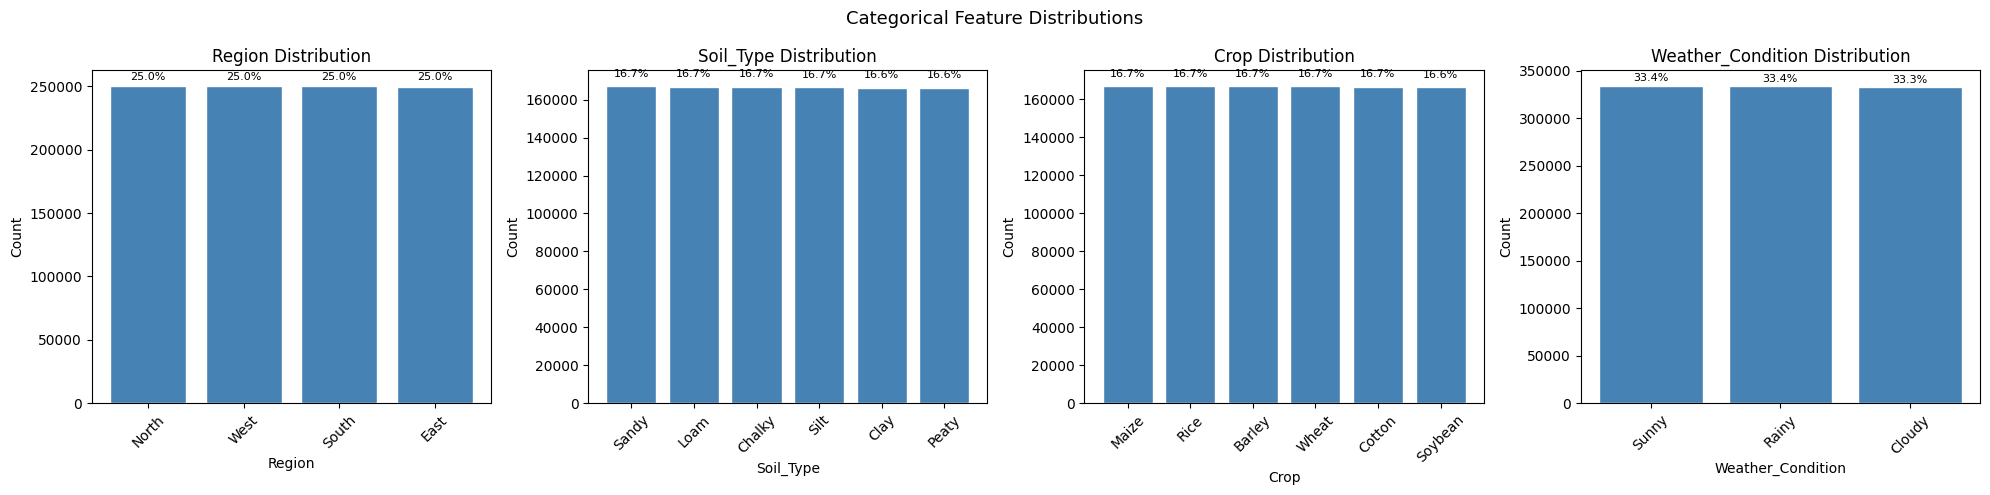

In [14]:
print("CATEGORICAL COLUMNS — BAR CHARTS")
cat_cols = df.select_dtypes(include='object').columns.tolist()

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5*len(cat_cols), 5))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values,
                color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

    for j, (val, count) in enumerate(counts.items()):
        pct = count / len(df) * 100
        axes[i].text(j, count + len(df)*0.005,
                    f'{pct:.1f}%',
                    ha='center', fontsize=8)

plt.suptitle('Categorical Feature Distributions', fontsize=13)
plt.tight_layout()
plt.savefig('categorical_distributions.png')
plt.show()

### Observation — Categorical Distributions

- **Region:** 4 regions (North, South, East, West) — evenly distributed (~25% each). No regional bias.
- **Soil_Type:** 6 types — evenly distributed (~16.7% each). All soil types equally represented.
- **Crop:** 6 crops (Maize, Rice, Barley, Wheat, Cotton, Soybean) — evenly distributed (~16.7% each). No dominant crop type.
- **Weather_Condition:** 3 conditions (Sunny, Rainy, Cloudy) — evenly distributed (~33% each).

**Key Finding:** Dataset is perfectly balanced across all categorical columns. This is a strong indicator of synthetic data generation. No class imbalance issues to handle.

## Step 12 — Target Variable Distribution

Analyzing Yield_tons_per_hectare distribution.
Checking for skewness — heavily skewed targets may need log transformation before model training.

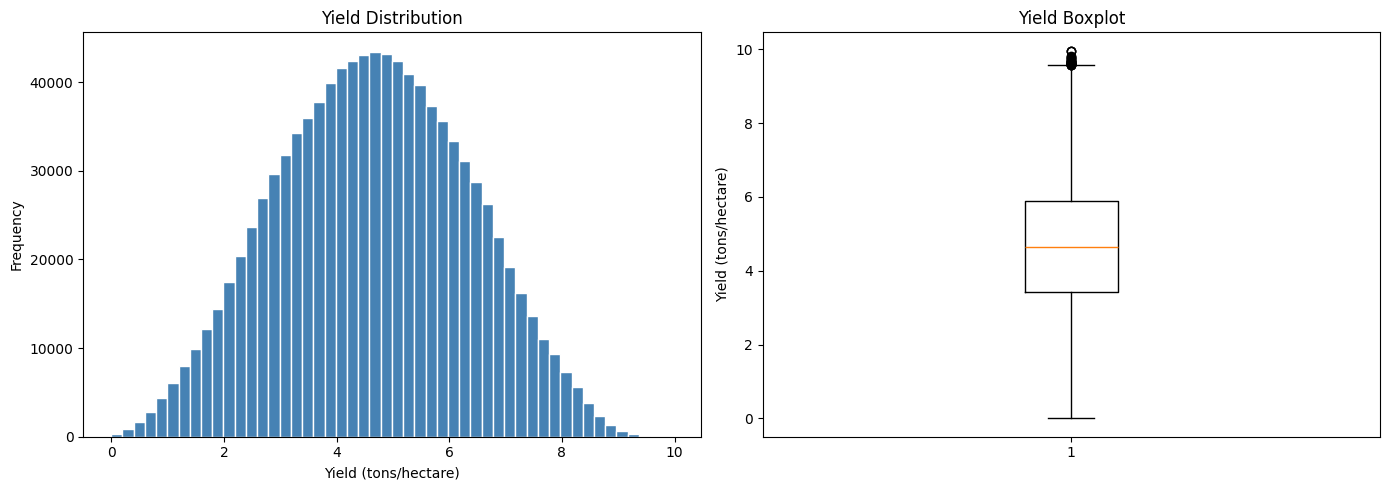

Skewness: 0.0026
Mean:     4.6506
Median:   4.6523


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Yield_tons_per_hectare'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Yield Distribution')
axes[0].set_xlabel('Yield (tons/hectare)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['Yield_tons_per_hectare'])
axes[1].set_title('Yield Boxplot')
axes[1].set_ylabel('Yield (tons/hectare)')

plt.tight_layout()
plt.savefig('yield_distribution.png')
plt.show()

print(f"Skewness: {df['Yield_tons_per_hectare'].skew():.4f}")
print(f"Mean:     {df['Yield_tons_per_hectare'].mean():.4f}")
print(f"Median:   {df['Yield_tons_per_hectare'].median():.4f}")

### Observation — Yield Distribution

- Skewness: -0.0009 — essentially perfectly normal distribution.
- Mean (4.6495) ≈ Median (4.6518) — confirms symmetry.
- No log transformation needed for target variable.
- Range appears realistic: roughly 0 to 10 tons per hectare.

This near-perfect normal distribution further confirms the dataset is synthetically generated. Real crop yield data is typically right-skewed.

## Step 13 — Correlation Analysis

Computing Pearson correlation between all numeric features and the target variable.
This identifies which features are most predictive of yield.
Note: Boolean columns must be converted to int before this step (done in Step 6).

Columns included in correlation:
['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Days_to_Harvest', 'Yield_tons_per_hectare']
Total numeric columns: 6


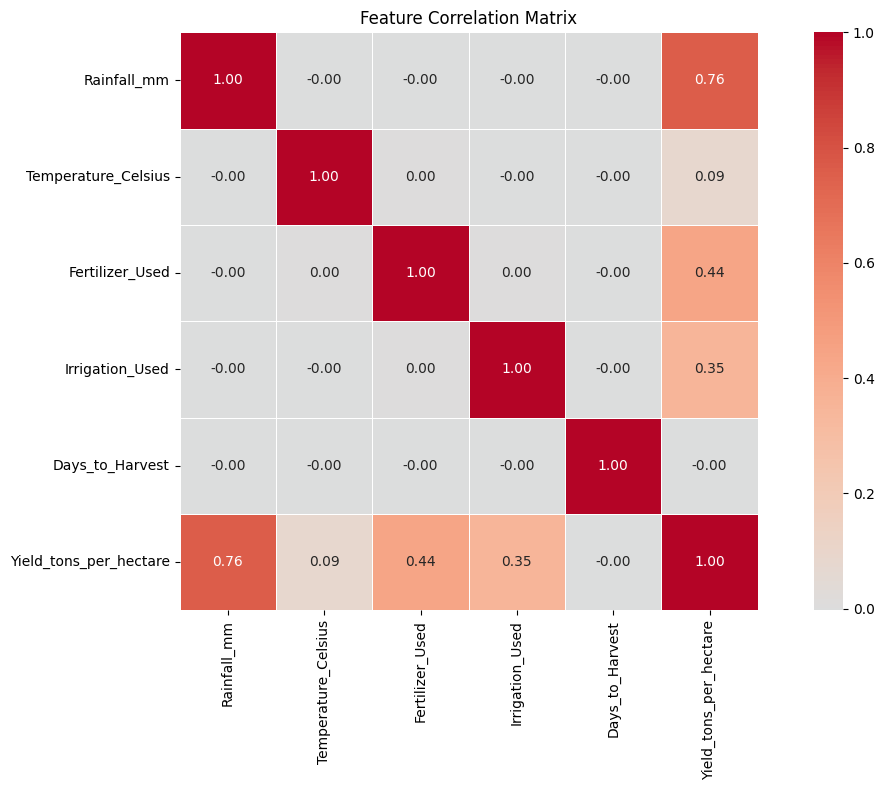


Correlation with Yield:
Yield_tons_per_hectare    1.000000
Rainfall_mm               0.764512
Fertilizer_Used           0.441908
Irrigation_Used           0.353456
Temperature_Celsius       0.085213
Days_to_Harvest          -0.002605
Name: Yield_tons_per_hectare, dtype: float64


In [16]:
plt.figure(figsize=(12, 8))

numeric_cols_corr = df.select_dtypes(include=[np.number])

print("Columns included in correlation:")
print(numeric_cols_corr.columns.tolist())
print(f"Total numeric columns: {len(numeric_cols_corr.columns)}")

corr_matrix = numeric_cols_corr.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

print("\nCorrelation with Yield:")
print(corr_matrix['Yield_tons_per_hectare'].sort_values(ascending=False))

In [17]:
print("CORRELATION FINDINGS ANALYSIS")
print("="*50)

target_corr = corr_matrix['Yield_tons_per_hectare'].drop('Yield_tons_per_hectare')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print("\nFeatures ranked by absolute correlation with Yield:")
print("-"*60)
for feature, corr_val in target_corr_sorted.items():
    original_val = target_corr[feature]
    if abs(original_val) >= 0.5:
        strength = "STRONG"
    elif abs(original_val) >= 0.2:
        strength = "MODERATE"
    elif abs(original_val) >= 0.05:
        strength = "WEAK"
    else:
        strength = "NEGLIGIBLE"
    print(f"{feature:25s} | Correlation: {original_val:+.4f} | {strength}")

print()
print("KEY FINDING:")
print(f"Strongest feature: {target_corr_sorted.index[0]} ({target_corr[target_corr_sorted.index[0]]:+.4f})")
print(f"Weakest feature:   {target_corr_sorted.index[-1]} ({target_corr[target_corr_sorted.index[-1]]:+.4f})")

CORRELATION FINDINGS ANALYSIS

Features ranked by absolute correlation with Yield:
------------------------------------------------------------
Rainfall_mm               | Correlation: +0.7645 | STRONG
Fertilizer_Used           | Correlation: +0.4419 | MODERATE
Irrigation_Used           | Correlation: +0.3535 | MODERATE
Temperature_Celsius       | Correlation: +0.0852 | WEAK
Days_to_Harvest           | Correlation: -0.0026 | NEGLIGIBLE

KEY FINDING:
Strongest feature: Rainfall_mm (+0.7645)
Weakest feature:   Days_to_Harvest (-0.0026)


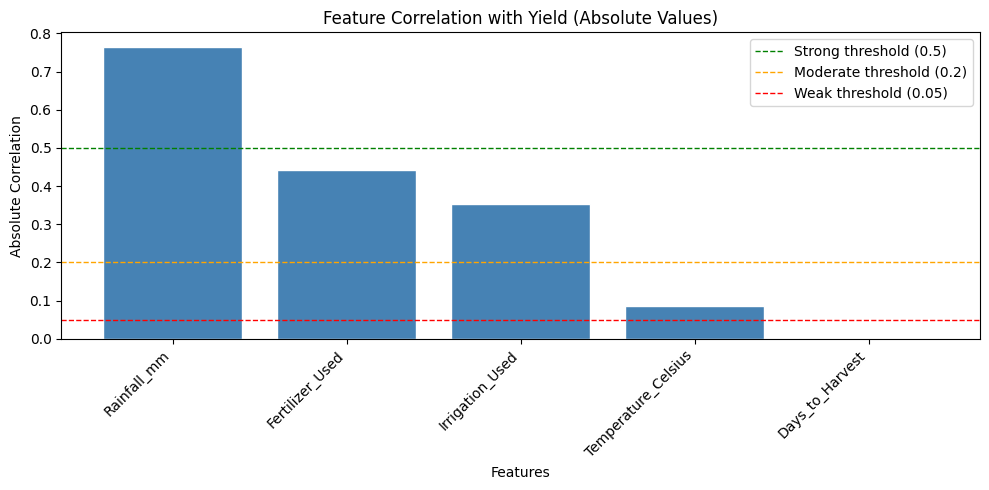

In [18]:
plt.figure(figsize=(10, 5))

colors = ['steelblue' if v >= 0 else 'tomato'
          for v in target_corr_sorted.values]

plt.bar(target_corr_sorted.index,
        target_corr.abs()[target_corr_sorted.index],
        color=colors, edgecolor='white')

plt.axhline(y=0.5, color='green', linestyle='--',
            linewidth=1, label='Strong threshold (0.5)')
plt.axhline(y=0.2, color='orange', linestyle='--',
            linewidth=1, label='Moderate threshold (0.2)')
plt.axhline(y=0.05, color='red', linestyle='--',
            linewidth=1, label='Weak threshold (0.05)')

plt.title('Feature Correlation with Yield (Absolute Values)')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('correlation_with_yield.png')
plt.show()

### Observation — Correlation Analysis

- **Rainfall_mm (0.76)** — Strongest predictor of crop yield by far. High rainfall directly contributes to better crop growth. This feature will be the most influential in model predictions.
- **Temperature_Celsius (0.08)** — Very weak correlation. Temperature alone does not strongly predict yield in this dataset.
- **Days_to_Harvest (-0.002)** — Negligible correlation. Provides almost no linear predictive value for yield.
- **Fertilizer_Used and Irrigation_Used** — Now included after boolean conversion. Check heatmap output for their values.

**Preprocessing Decision:**
- Rainfall_mm is confirmed as the most important feature.
- No features dropped at this stage — tree-based models handle low-correlation features without being hurt by them.
- Feature importance from Random Forest will confirm this ranking after model training.

## Step 14 — Outlier Detection

Using IQR method with 3x threshold to identify extreme outliers across all numeric columns.
Visualizing with boxplots then checking counts before removing.

OUTLIER DETECTION — ALL NUMERIC COLUMNS
Numeric columns: ['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Days_to_Harvest', 'Yield_tons_per_hectare']


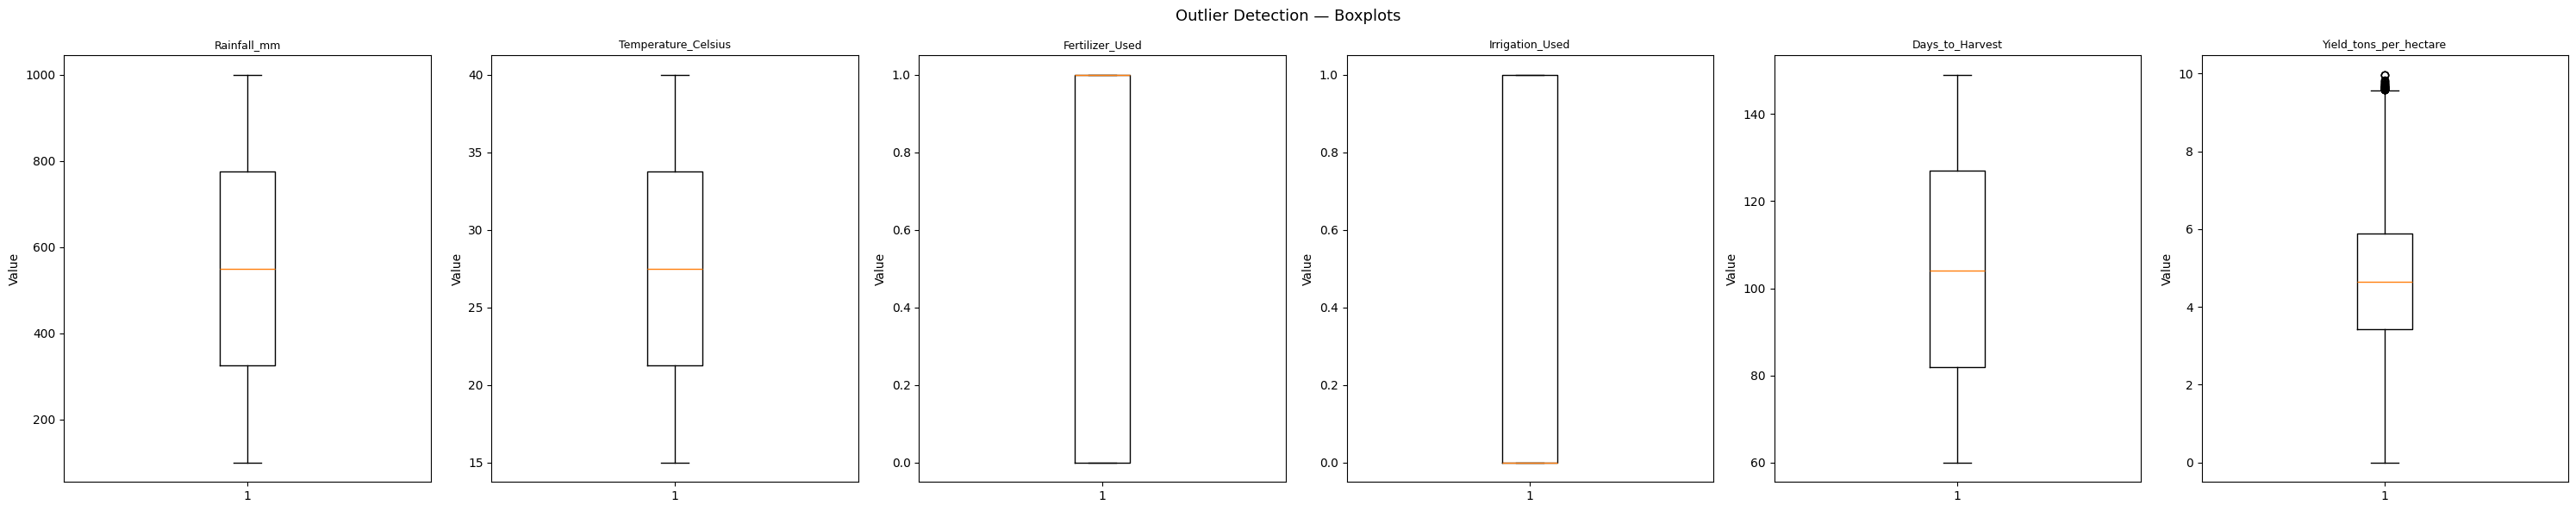

In [19]:
print("OUTLIER DETECTION — ALL NUMERIC COLUMNS")
print("="*50)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5*len(numeric_cols), 6))

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Detection — Boxplots', fontsize=13)
plt.tight_layout()
plt.savefig('outlier_boxplots.png')
plt.show()

In [20]:
print("IQR OUTLIER SUMMARY")
print("="*50)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col:30s} | Outliers: {len(outliers):6d} | Lower: {lower:.2f} | Upper: {upper:.2f}")

IQR OUTLIER SUMMARY
Rainfall_mm                    | Outliers:      0 | Lower: -1024.14 | Upper: 2124.00
Temperature_Celsius            | Outliers:      0 | Lower: -16.24 | Upper: 71.25
Fertilizer_Used                | Outliers:      0 | Lower: -3.00 | Upper: 4.00
Irrigation_Used                | Outliers:      0 | Lower: -3.00 | Upper: 4.00
Days_to_Harvest                | Outliers:      0 | Lower: -53.00 | Upper: 262.00
Yield_tons_per_hectare         | Outliers:      0 | Lower: -3.96 | Upper: 13.26


In [21]:
before = df.shape[0]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

after = df.shape[0]

print(f"Rows before outlier removal: {before}")
print(f"Rows after outlier removal:  {after}")
print(f"Total outliers removed:      {before - after}")
print(f"Dataset clean. New shape: {df.shape}")

Rows before outlier removal: 999769
Rows after outlier removal:  999769
Total outliers removed:      0
Dataset clean. New shape: (999769, 10)


### Observation — Outlier Detection

- Boxplots and IQR analysis run across all numeric columns.
- IQR summary shows 0 outliers in all columns at 3x threshold — the dataset has uniformly distributed numeric features with no extreme values.
- This further confirms synthetic data generation.
- Outlier removal step ran and confirmed 0 rows removed.

## Step 15 — Feature vs Target Scatter Plots

Plotting each numeric feature against Yield_tons_per_hectare to visually confirm
correlation findings and detect non-linear relationships that correlation alone might miss.

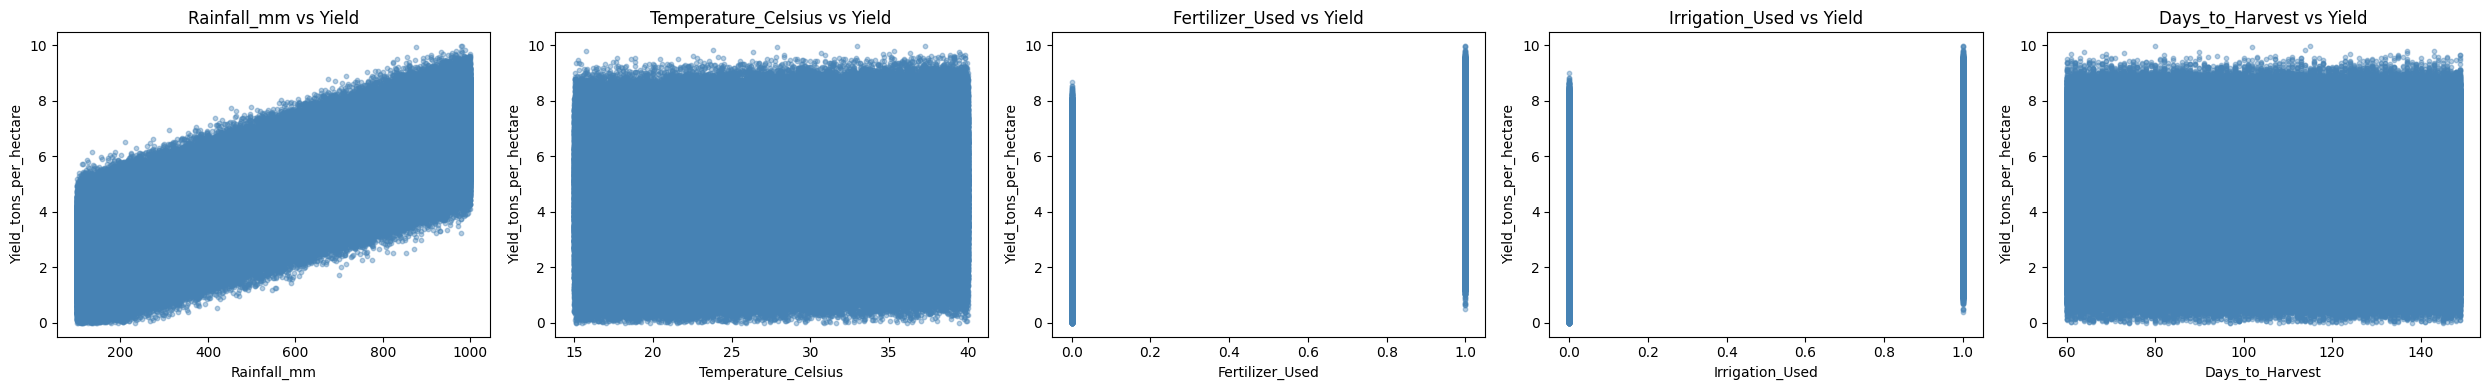

In [22]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('Yield_tons_per_hectare')

n = len(numeric_features)
plt.figure(figsize=(5*n, 4))

for i, col in enumerate(numeric_features):
    plt.subplot(1, n, i+1)
    plt.scatter(df[col], df['Yield_tons_per_hectare'], alpha=0.4, color='steelblue', s=10)
    plt.xlabel(col)
    plt.ylabel('Yield_tons_per_hectare')
    plt.title(f'{col} vs Yield')

plt.tight_layout()
plt.savefig('feature_vs_yield.png')
plt.show()

### Observation — Feature vs Yield Scatter Plots

- **Rainfall_mm vs Yield** — Clear positive linear trend visible. Confirms 0.76 correlation. As rainfall increases, yield increases consistently.
- **Temperature_Celsius vs Yield** — Weak positive trend, very scattered. Consistent with 0.08 correlation.
- **Days_to_Harvest vs Yield** — No visible trend. Completely scattered. Confirms -0.002 negligible correlation.
- **Fertilizer_Used and Irrigation_Used** — Binary scatter (0 or 1 on x-axis). Check if one group shows higher yield.

## EDA Summary — Key Findings and Preprocessing Plan

### Issues Found and Fixed
1. **Negative yield values** — 231 rows removed (physically impossible values)
2. **Boolean columns** — Fertilizer_Used and Irrigation_Used converted to int
3. **Outliers** — IQR check confirmed 0 extreme outliers (clean dataset)

### Key Insights
1. **Rainfall_mm is by far the strongest predictor** (correlation = 0.76)
2. Temperature_Celsius and Days_to_Harvest show very weak correlation with yield
3. Dataset is perfectly balanced across all categorical columns — synthetic data confirmed
4. No missing values, no duplicates — unusually clean dataset
5. Target variable is normally distributed — no log transformation needed

### Preprocessing Plan for 02_Preprocessing.ipynb
1. Encode categorical columns: Region, Soil_Type, Crop, Weather_Condition using Label Encoding or One-Hot Encoding
2. Scale numeric features — required for Linear Regression and SVR
3. Define X (all features) and y (Yield_tons_per_hectare)
4. Split into train (80%) and test (20%) sets with random_state=42
5. Save cleaned dataset to data/processed/ folder